<a href="https://colab.research.google.com/github/A-Vineela/IIIT-H-Summer-School-2026/blob/main/GPT_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 A Rapid Recap of Transformers

> *"Attention is all you need"* — Vaswani et al., 2017. One architecture, and it ate the entire field.
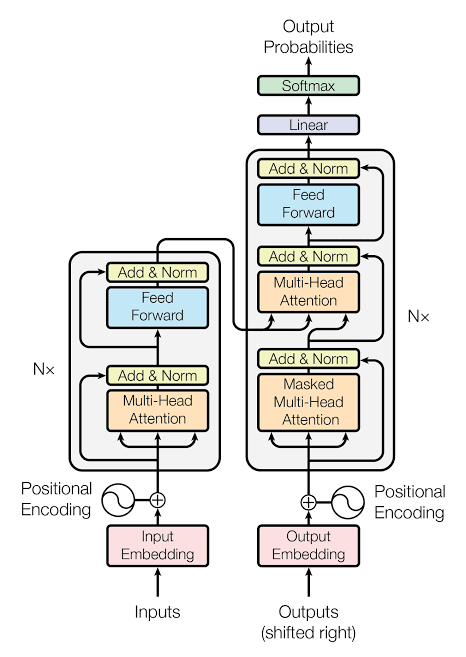
---

## The Transformer architecture


<div style="display:flex; justify-content:center; gap:40px; margin:20px 0; font-family:monospace; text-align:center;">
  <div style="border:2px solid #4a90d9; border-radius:10px; padding:14px 22px; background:rgba(74,144,217,0.08);">
    <b style="color:#4a90d9;">ENCODER</b><br><br>
    <div style="border:1px solid #999; border-radius:6px; padding:6px; margin:5px;">Feed Forward</div>
    <div style="border:1px solid #999; border-radius:6px; padding:6px; margin:5px;">Self-Attention</div>
    <div style="margin-top:8px;">⬆️ × N layers</div>
    <div style="margin-top:8px; font-size:12px;">reads the <b>whole input at once</b></div>
  </div>
  <div style="align-self:center; font-size:28px;">➡️</div>
  <div style="border:2px solid #d97a4a; border-radius:10px; padding:14px 22px; background:rgba(217,122,74,0.08);">
    <b style="color:#d97a4a;">DECODER</b><br><br>
    <div style="border:1px solid #999; border-radius:6px; padding:6px; margin:5px;">Feed Forward</div>
    <div style="border:1px solid #999; border-radius:6px; padding:6px; margin:5px;">Cross-Attention</div>
    <div style="border:1px solid #999; border-radius:6px; padding:6px; margin:5px;">Masked Self-Attention</div>
    <div style="margin-top:8px;">⬆️ × N layers</div>
    <div style="margin-top:8px; font-size:12px;">generates output <b>one token at a time</b></div>
  </div>
</div>

**The core idea:** throw away recurrence (RNNs/LSTMs). Instead, let every token *directly look at* every other token, in parallel. That's attention.

---

## 🔍 Self-Attention — "which words should I pay attention to?"

Every token creates three vectors from its embedding, via learned matrices:

| Vector | Intuition |
|---|---|
| **Q** — Query | *"What am I looking for?"* |
| **K** — Key | *"What do I contain?"* |
| **V** — Value | *"What information do I actually give you?"* |

The famous one-liner:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

Read it left to right:

1. $QK^\top$ → compare every query with every key = **similarity scores** between all token pairs
2. $\sqrt{d_k}$ → just a scaling trick so softmax doesn't saturate
3. $\text{softmax}$ → turn scores into **attention weights** that sum to 1
4. $\cdot\,V$ → each token becomes a **weighted mix of everyone's values**

**Example:** in *"The animal didn't cross the street because **it** was tired"* — the token **it** sends out a query, the key of **animal** matches strongly, so **it** absorbs the meaning of **animal**. Context, resolved in one matrix multiply. ✨

---

## 🎭 Why *Multiple* Heads?

One attention pattern = one "notion of relevance." But language needs many at the same time:

<div style="display:flex; gap:14px; justify-content:center; flex-wrap:wrap; margin:16px 0; text-align:center; font-size:14px;">
  <div style="border:1px solid #7a5ad9; border-radius:8px; padding:10px 16px;">🧩 Head 1<br><b>syntax</b><br><i>verb ↔ subject</i></div>
  <div style="border:1px solid #5ad98f; border-radius:8px; padding:10px 16px;">🔗 Head 2<br><b>coreference</b><br><i>"it" ↔ "animal"</i></div>
  <div style="border:1px solid #d9c15a; border-radius:8px; padding:10px 16px;">📍 Head 3<br><b>position</b><br><i>previous word</i></div>
  <div style="border:1px solid #d95a5a; border-radius:8px; padding:10px 16px;">💡 Head 4<br><b>semantics</b><br><i>"tired" ↔ "rest"</i></div>
</div>

Each head runs the same attention formula with its **own smaller Q, K, V projections**, in parallel. Outputs are concatenated and mixed:

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h)\,W^O$$

> 💬 **Analogy:** one head is one person reading the sentence with one question in mind. Multiple heads = a panel of readers, each looking for something different, then pooling notes.

---

## 🔁 Cross-Attention — "look at the *other* sequence"

Same formula, different source of Q vs K, V:

| | Queries come from | Keys & Values come from |
|---|---|---|
| **Self-attention** | the sequence itself | the *same* sequence |
| **Cross-attention** | the **decoder** (output so far) | the **encoder** (input) |

This is how a translation model, while writing the French word #7, peeks back at the *entire English sentence* to decide what to say next. The decoder asks the questions; the encoder holds the answers.

---

## ⚔️ BERT vs GPT — same blocks, opposite philosophies


<div style="display:flex; justify-content:center; gap:30px; margin:16px 0; text-align:center;">
  <div style="border:2px solid #4a90d9; border-radius:10px; padding:14px 20px; width:290px;">
    <b style="color:#4a90d9; font-size:17px;">BERT (2018)</b><br>
    <i>Encoder-only</i><br><br>
    👀 sees the sentence <b>both directions</b><br><br>
    Trained by <b>Masked LM</b>:<br>
    <code>The [MASK] sat on the mat</code><br>
    → predict <code>cat</code><br><br>
    🏆 <b>Understanding</b>: classification, search, NER
  </div>
  <div style="border:2px solid #d97a4a; border-radius:10px; padding:14px 20px; width:290px;">
    <b style="color:#d97a4a; font-size:17px;">GPT (2018–…)</b><br>
    <i>Decoder-only</i><br><br>
    👀 sees <b>only the past</b> (causal mask)<br><br>
    Trained by <b>Next-Token Prediction</b>:<br>
    <code>The cat sat on the</code><br>
    → predict <code>mat</code><br><br>
    🏆 <b>Generation</b>: chat, code, reasoning — every modern LLM
  </div>
</div>

**Why did GPT win the LLM era?** Next-token prediction is *one simple objective* that scales beautifully: every token in the internet is a training example, and generation falls out for free. Bidirectionality is great for understanding — but you can't easily *generate* with it.

> 🧭 **Everything we build today is a decoder-only transformer.** Keep this picture in your head — we're about to write one from scratch.

# 🏗️ Part 1 — Building a Tiny GPT from Scratch

We'll train a small character-level GPT on **Tiny Shakespeare** — the complete works of Shakespeare in one text file (~1 MB). Small enough to train in minutes, real enough to learn actual English structure.

**Step 1: Get the data and look at it.** Always look at your data first. 👀

In [1]:
import urllib.request

# Download Tiny Shakespeare (~1.1 MB, single .txt file)
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
urllib.request.urlretrieve(url, "input.txt")

with open("input.txt", "r", encoding="utf-8") as f:
    text = f.read()

print(f"Total characters in dataset: {len(text):,}")
print(f"Unique characters (our 'vocabulary'): {len(set(text))}")
print("-" * 60)
print("First 500 characters:")
print("-" * 60)
print(text[:500])

Total characters in dataset: 1,115,394
Unique characters (our 'vocabulary'): 65
------------------------------------------------------------
First 500 characters:
------------------------------------------------------------
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor


## 🔤 Step 2: Tokenization — text → numbers

Neural networks eat numbers, not letters. Since we're character-level, our tokenizer is beautifully simple: **each unique character gets an integer ID.**

To see how GPT Tokenizers work look into - https://tiktokenizer.vercel.app/

> Real LLMs use subword tokenizers (BPE) with ~50k–150k tokens — same idea, bigger vocabulary. `"hello"` might be one token; here it's 5.

In [2]:
import torch

# Build the vocabulary: every unique character, sorted
chars = sorted(set(text))
vocab_size = len(chars)
print(f"Vocabulary ({vocab_size} chars): {''.join(chars)!r}")

# Two tiny lookup tables
stoi = {ch: i for i, ch in enumerate(chars)}   # string -> integer
itos = {i: ch for i, ch in enumerate(chars)}   # integer -> string

encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: ''.join(itos[i] for i in ids)

# Demo: round-trip a string
sample = "Hello Shakespeare!"
ids = encode(sample)
print(f"\n'{sample}'")
print(f"→ encoded: {ids}")
print(f"→ decoded back: '{decode(ids)}'")

# Encode the ENTIRE dataset into one tensor
data = torch.tensor(encode(text), dtype=torch.long)
print(f"\nFull dataset as tensor: shape={data.shape}, dtype={data.dtype}")
print(f"First 50 token IDs: {data[:50].tolist()}")

Vocabulary (65 chars): "\n !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz"

'Hello Shakespeare!'
→ encoded: [20, 43, 50, 50, 53, 1, 31, 46, 39, 49, 43, 57, 54, 43, 39, 56, 43, 2]
→ decoded back: 'Hello Shakespeare!'

Full dataset as tensor: shape=torch.Size([1115394]), dtype=torch.int64
First 50 token IDs: [18, 47, 56, 57, 58, 1, 15, 47, 58, 47, 64, 43, 52, 10, 0, 14, 43, 44, 53, 56, 43, 1, 61, 43, 1, 54, 56, 53, 41, 43, 43, 42, 1, 39, 52, 63, 1, 44, 59, 56, 58, 46, 43, 56, 6, 1, 46, 43, 39, 56]


## ⚙️ Step 3: The Full Tiny GPT

Everything from the recap, now in code. Read it top-down — it maps 1:1 to the architecture diagram:

- **`Head`** → the attention formula $\text{softmax}(QK^\top/\sqrt{d_k})V$ + causal mask (GPT only sees the past)
- **`MultiHeadAttention`** → several heads in parallel, concatenated
- **`FeedForward`** → the MLP block
- **`Block`** → attention + MLP, with residual connections & LayerNorm
- **`TinyGPT`** → token + position embeddings → N blocks → predict next token

~**0.8M parameters**. GPT-3 is the same skeleton with ~200,000× more.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(1337)

# ---------------- Hyperparameters ----------------
batch_size = 64      # sequences per batch
block_size = 128     # context length (max chars the model sees)
n_embd     = 128     # embedding dimension
n_head     = 4       # attention heads
n_layer    = 4       # transformer blocks
dropout    = 0.1
device     = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# ---------------- Train / val split ----------------
n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

def get_batch(split):
    """Sample a random batch. y is x shifted by one -> next-char prediction."""
    d = train_data if split == 'train' else val_data
    ix = torch.randint(len(d) - block_size, (batch_size,))
    x = torch.stack([d[i:i+block_size] for i in ix])
    y = torch.stack([d[i+1:i+block_size+1] for i in ix])
    return x.to(device), y.to(device)

# ---------------- One attention head ----------------
class Head(nn.Module):
    def __init__(self, head_size):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        # causal mask: token i may only attend to tokens <= i
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k, q, v = self.key(x), self.query(x), self.value(x)
        # THE formula: softmax(QK^T / sqrt(d_k)) V
        wei = q @ k.transpose(-2, -1) * k.shape[-1]**-0.5     # (B, T, T)
        wei = wei.masked_fill(self.tril[:T, :T] == 0, float('-inf'))  # no peeking ahead!
        wei = F.softmax(wei, dim=-1)
        wei = self.dropout(wei)
        return wei @ v

# ---------------- Multi-head attention ----------------
class MultiHeadAttention(nn.Module):
    def __init__(self, n_head, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(n_head)])
        self.proj  = nn.Linear(n_embd, n_embd)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)  # concat heads
        return self.dropout(self.proj(out))

# ---------------- Feed-forward (MLP) ----------------
class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )
    def forward(self, x):
        return self.net(x)

# ---------------- Transformer block ----------------
class Block(nn.Module):
    def __init__(self):
        super().__init__()
        self.sa   = MultiHeadAttention(n_head, n_embd // n_head)
        self.ffwd = FeedForward()
        self.ln1  = nn.LayerNorm(n_embd)
        self.ln2  = nn.LayerNorm(n_embd)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))     # residual + attention
        x = x + self.ffwd(self.ln2(x))   # residual + MLP
        return x

# ---------------- The full model ----------------
class TinyGPT(nn.Module):
    def __init__(self):
        super().__init__()
        self.token_emb    = nn.Embedding(vocab_size, n_embd)
        self.position_emb = nn.Embedding(block_size, n_embd)
        self.blocks  = nn.Sequential(*[Block() for _ in range(n_layer)])
        self.ln_f    = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size)  # logits over vocabulary

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok = self.token_emb(idx)                                   # what the token is
        pos = self.position_emb(torch.arange(T, device=device))     # where it is
        x = self.blocks(tok + pos)
        logits = self.lm_head(self.ln_f(x))                         # (B, T, vocab_size)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(B*T, -1), targets.view(B*T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens):
        """Autoregressive generation: predict, sample, append, repeat."""
        for _ in range(max_new_tokens):
            logits, _ = self(idx[:, -block_size:])   # crop to context window
            probs = F.softmax(logits[:, -1, :], dim=-1)  # last position only
            idx = torch.cat([idx, torch.multinomial(probs, 1)], dim=1)
        return idx

model = TinyGPT().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"TinyGPT ready: {n_params/1e6:.2f}M parameters, {n_layer} layers, {n_head} heads")

Using device: cuda
TinyGPT ready: 0.82M parameters, 4 layers, 4 heads


## 🚀 Step 4: Train the model

First, let's see what an **untrained** model produces (spoiler: pure noise). Then we train for a few minutes and generate again.

The training loop is just 4 lines that every neural net ever uses: forward → loss → backward → step. Repeated a few thousand times.

In [4]:
import time

# ---------- BEFORE training: pure gibberish ----------
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print("=" * 60)
print("BEFORE TRAINING:")
print("=" * 60)
print(decode(model.generate(context, max_new_tokens=200)[0].tolist()))

# ---------- Training setup ----------
max_iters     = 6000
eval_interval = 500
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    for split in ['train', 'val']:
        losses = torch.zeros(50)
        for k in range(50):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean().item()
    model.train()
    return out

# ---------- The training loop ----------
print("\n" + "=" * 60)
print("TRAINING...")
print("=" * 60)
t0 = time.time()

for it in range(max_iters + 1):
    if it % eval_interval == 0:
        losses = estimate_loss()
        print(f"step {it:5d} | train loss {losses['train']:.3f} | "
              f"val loss {losses['val']:.3f} | {time.time()-t0:.0f}s")

    xb, yb = get_batch('train')             # 1. get a batch
    logits, loss = model(xb, yb)            # 2. forward pass -> loss
    optimizer.zero_grad(set_to_none=True)
    loss.backward()                         # 3. backprop
    optimizer.step()                        # 4. update weights

# ---------- AFTER training ----------
print("\n" + "=" * 60)
print("AFTER TRAINING:")
print("=" * 60)
print(decode(model.generate(context, max_new_tokens=400)[0].tolist()))

BEFORE TRAINING:

TvNemW;JQejkSLWfJLUJGLBcET'u;rcFc&NNhY$eQLJEOERWgIjNhhqv;EW
mawD&ZqC&CgWL'PR$n,HGjX.VSumfhIHWz?nAHpNVCe!IeQiqfeSEuOt3Zw?Mjx$n?yuwPmuUvK&bdVue eJjR$KasVXgevEEYpK!X'ucpahkiEba$iol$CUG?XGKtFwSsMvJ!BmV?&D

TRAINING...
step     0 | train loss 4.349 | val loss 4.346 | 2s
step   500 | train loss 2.324 | val loss 2.333 | 27s
step  1000 | train loss 2.028 | val loss 2.074 | 44s
step  1500 | train loss 1.844 | val loss 1.943 | 62s
step  2000 | train loss 1.722 | val loss 1.868 | 80s
step  2500 | train loss 1.635 | val loss 1.803 | 105s
step  3000 | train loss 1.586 | val loss 1.755 | 123s
step  3500 | train loss 1.540 | val loss 1.721 | 141s
step  4000 | train loss 1.510 | val loss 1.689 | 160s
step  4500 | train loss 1.480 | val loss 1.674 | 179s
step  5000 | train loss 1.461 | val loss 1.639 | 197s
step  5500 | train loss 1.431 | val loss 1.625 | 216s
step  6000 | train loss 1.422 | val loss 1.606 | 235s

AFTER TRAINING:

ANT:
O, mosSecond me were I am infoked; proclots, what

Lets now use a better model imported from Hugging Face

In [5]:
# !pip install -q transformers accelerate

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# Qwen2.5-0.5B — a real pretrained BASE model, small enough for any Colab GPU
model_name = "Qwen/Qwen2.5-0.5B"

tokenizer = AutoTokenizer.from_pretrained(model_name)
base_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
print(f"Loaded {model_name}: {base_model.num_parameters()/1e6:.0f}M parameters\n")

# Ask it a question
prompt = "What is the capital of France?"

inputs = tokenizer(prompt, return_tensors="pt").to(base_model.device)
output = base_model.generate(
    **inputs,
    max_new_tokens=80,
    do_sample=True,
    temperature=0.7,
    top_p=0.9,
)
print("PROMPT:", prompt)
print("-" * 60)
print(tokenizer.decode(output[0], skip_special_tokens=True))

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.23k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B /  988MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

Loaded Qwen/Qwen2.5-0.5B: 494M parameters

PROMPT: What is the capital of France?
------------------------------------------------------------
What is the capital of France? Paris


---

# 🙏 Thank You!

### We will get an overview of the entire modern LLM stack:
**Tiny GPT from scratch → Fine-tuning → RLHF/DPO → APIs → Structured Outputs → RAG → Agents**

<div style="text-align:center; margin:24px 0;">
  <img src="https://drive.google.com/uc?id=1TggnfOXRq5F_UaVDQuBJgQYy-GCDkGIb" width="180" style="border-radius:12px;"/>
  <br><br>
  <b>Souvik</b><br>
  <span style="font-size:14px;">📱 Scan for my socials — questions and feedback!</span>
</div>

*CVIT AI Summer School 2026 — Hands-on LLM Session*